# import

In [22]:
import tensorflow as tf
assert tf.__version__.split('.')[0] == '2'
tf.__version__

'2.0.0-alpha0'

In [23]:
model_dir = '../data/models'

In [24]:
import collections, os, pickle, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

%load_ext autoreload
%autoreload 2

In [25]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, features, settings, signals as S, util

# make dataset

generation of efficient matrix-based training/eval sets

see below "use" section for streaming implementations

In [26]:
ab = abase.ABase()
ab.load('logmel')

loaded 36/35 (102.86%)


'o_g_5'

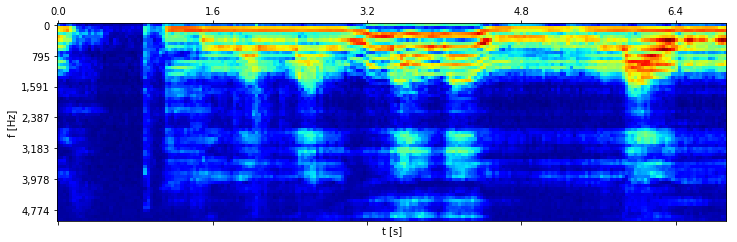

In [27]:
name = ab.sample()
util.plot_logmel(ab.df.loc[name, 'logmel'])
name

In [28]:
ab_train = ab.query('rand_stable > 0.2')
ab_test = ab.query('rand_stable <= 0.2')
print('\n'.join([str(ab_train), str(ab_test)]))

ABase(n=28, series=7, what=o:12|t:12|m:4, who=g:11|p:9|a:8)
ABase(n=7, series=6, what=o:3|t:2|m:1|w:1, who=g:4|a:3)


/Users/andreassteiner/git/rizhom/env/lib/python3.7/site-packages/pandas/core/generic.py:5079: FutureWarning: Attribute 'is_copy' is deprecated and will be removed in a future version.
  object.__getattribute__(self, name)
/Users/andreassteiner/git/rizhom/env/lib/python3.7/site-packages/pandas/core/generic.py:5080: FutureWarning: Attribute 'is_copy' is deprecated and will be removed in a future version.
  return object.__setattr__(self, name, value)


In [29]:
DataSet = collections.namedtuple('DataSet', ['x', 'y', 'idxs'])

def x_vs_y(df, x, y):
    """Returns .query(x) (y=0) vs. .query(y) (y=1)."""
    x0s = list(df.query(x).logmel.values)
    x1s = list(df.query(y).logmel.values)
    x0 = np.concatenate(x0s, axis=0)
    x1 = np.concatenate(x1s, axis=0)
    x = np.concatenate([x0, x1])
    y = np.concatenate([
        np.zeros(x0.shape[0], dtype=np.int64),
        np.ones(x1.shape[0], dtype=np.int64),
    ])
    idxs = [len(_) for _ in x0s] + [len(_) for _ in x1s]
    return DataSet(x, y, idxs)

def t_vs_o(df):
    return x_vs_y(df, x='what == "t"', y='what == "o"')

def tm_vs_o(df):
    return x_vs_y(df, x='what == "t" or what =="m"', y='what == "o"')

from PIL import Image

def pad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = 0
    for idx in ds.idxs:
        x_.append(np.pad(ds.x[i0:i0 + idx], ((pad_width, pad_width), (0, 0)), mode='constant'))
        y_.append(np.pad(ds.y[i0:i0 + idx], ((pad_width, pad_width),), mode='constant'))
        idxs_.append(idx + 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def unpad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = pad_width
    for idx in ds.idxs:
        x_.append(ds.x[i0:i0 + idx - 2 * pad_width])
        y_.append(ds.y[i0:i0 + idx - 2 * pad_width])
        idxs_.append(idx - 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def with_previous(ds, n, d=None):
    """Concatenates features with average from previous frames.

    Args:
      n: how many (preceeding) frames to consider
      d: dimension of the added vector (defaults to same dimensions as `x`)
    """
    padded = pad(ds, pad_width=n)
    w, h = padded.x.shape
    if d is None:
        d = h
    augmented = np.zeros((w, h + d))
    augmented[:, :h] = padded.x
    x = padded.x
    if d != h:
        x = np.array(Image.fromarray(x).resize((d, x.shape[0])))
    for i in range(n):
        augmented[:, h:] += np.roll(x, i, axis=0) / n
    return unpad(DataSet(augmented, padded.y, padded.idxs), pad_width=n)

((5208, 84), (5208,), [217, 217, 217, 217, 217, 217, 217, 217, 217, 217])

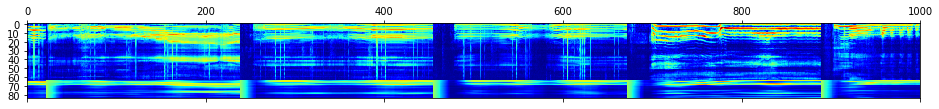

In [30]:
n, d = 20, 20
ds = with_previous(t_vs_o(ab_train.df), n=n, d=d)

plt.matshow(ds.x[2800:3800, :].T, cmap='jet')
ds.x.shape, ds.y.shape, ds.idxs[:10]

# train

## conf

In [85]:
class TfConf(object):
    def __init__(self, **kwargs):
        self.data = dict(**kwargs)
    def spawn(self, **kwargs):
        return TfConf(**{k:v for k, v in self.data.items()
                         if k not in kwargs}, **kwargs)
    def __setattr__(self, k, v):
        if k =='data':
            object.__setattr__(self, k, v)
            return
        assert k in self.data
        self.data[k] = v
    def __getattr__(self, k):
        return self.__getattribute__('data')[k]
    def __str__(self):
        return 'TfConf({})'.format(' '.join([
            '{}={}'.format(k, v)
            for k, v in sorted(self.data.items())
        ]))
    def __repr__(self):
        return str(self)
    def name(self, keys):
        return '-'.join(['{}={}'.format(k, v)
                         for k, v in self.data.items() if k in keys])

c = TfConf(a=1, b=2)
c.spawn(c=3, b=2.5)

conf_base = TfConf(
    features='logmel',
    # tm_o : text/music vs. o
    # t_o : text vs. o
    classes='tm_o',
    # How to preprocess features : none, wp_{n}_{d}
    preprocessor='none',
    epochs=15,
    batch_size=10,
    optimizer='SGD',
    units=(),
    # tf.keras.model.fit(verbose)
    verbose=1,
    # name of the experiment
    experiment=None,
    # per experiment
    runs=3,
)

## train, experiment

In [175]:
TrainEvalResults = collections.namedtuple('TrainEvalResults', ['conf', 'model', 'history', 'metrics'])

def make_ds(conf, df):
    if conf.classes == 't_o':
        ds = x_vs_y(df, 'what == "t"', 'what == "o"')
    elif conf.classes == 'tm_o':
        ds = x_vs_y(df, 'what == "t" or what == "m"', 'what == "o"')
    else:
        raise ValueError('unknown classes: "{}"'.format(conf.classes))
    if conf.preprocessor == 'none':
        pass
    elif conf.preprocessor[:3] == 'wp_':
        parts = conf.preprocessor.split('_')
        ds = with_previous(ds, n=int(parts[1]), d=int(parts[2]))
    else:
        raise ValueError('unknown preprocessor: "{}"'.formatr(conf.preprocessor))
    return ds

def make_xy_tensors(conf, df):
    ds = make_ds(conf, df)
    return (
        tf.convert_to_tensor(ds.x),
        tf.one_hot(ds.y, depth=2, dtype=tf.float32),
    )

def train_eval(conf):
    global ab_train, ab_test
    
    train_xy = make_xy_tensors(conf, ab_train.df)

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[train_xy[0].shape[1]]),
    ] + [
        tf.keras.layers.Dense(units=units, activation='relu')
        for units in conf.units
    ] + [
        tf.keras.layers.Dense(units=2, activation='softmax'),
    ])

    if conf.optimizer == 'SGD':
        optimizer = tf.optimizers.SGD()
    else:
        raise ValueError('unknown optimizer: "{}"'.formatr(conf.optimizer))

    if conf.verbose:
        model.summary()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(*train_xy, epochs=conf.epochs,
                        batch_size=conf.batch_size, verbose=conf.verbose)

    metrics = dict(zip(
        model.metrics_names,
        model.evaluate(*make_xy_tensors(conf, ab_test.df),
                       verbose=conf.verbose),
    ))

    return TrainEvalResults(conf=conf, model=model, history=history.history,
                            metrics=metrics)

In [115]:
def mean_std(results, metric):
    values = np.array([result.metrics[metric] for result in results])
    return values.mean(), values.std()

def experiments(confs, keys):
    results = []
    for i, conf in enumerate(confs):
        name = '-'.join([str(conf.data[k]) for k in keys])
        print('#%03d %20s' % (i, name), end=': ')
        results.append([])
        for j in range(conf.runs):
            t0 = time.time()
            result = train_eval(conf)
            result.metrics['dt'] = time.time() - t0
            results[-1].append(result)
            print('%.4f' % result.metrics['accuracy'], end=', ')
        print(' -> %.4f ± %.4f' % mean_std(results[-1], 'accuracy'), end=' ')
        print(' [%.1fs ± %.1fs]' % mean_std(results[-1], 'dt'))
    return results

### test

Model: "sequential_171"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_173 (Flatten)        (None, 64)                0         
_________________________________________________________________
dense_261 (Dense)            (None, 2)                 130       
Total params: 130
Trainable params: 130
Non-trainable params: 0
_________________________________________________________________
Epoch 1/2
6076/6076 [==============================] - 1s 191us/sample - loss: 0.7333 - accuracy: 0.6350 - loss: 0.7338 - accuracy: 0.63
Epoch 2/2
1302/1302 [==============================] - 0s 77us/sample - loss: 0.4278 - accuracy: 0.8295


{'loss': 0.42778429503448184, 'accuracy': 0.8294931}

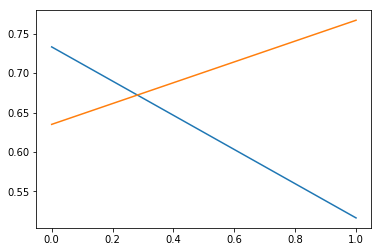

In [106]:
ter = train_eval(conf_base.spawn(epochs=2))
plt.plot(ter.history['loss'])
plt.plot(ter.history['accuracy'])
ter.metrics

## experiments

In [177]:
def save(name, result):
    """Stores {name}.h5 & {name}_*.json in `model_dir`."""
    result.model.save(os.path.join(model_dir, '{}.h5'.format(name)))
    for what, d in (('conf', result.conf.data), ('metrics', result.metrics),
                    ('history', result.history)):
        with open(os.path.join(model_dir, '{}_{}.json'.format(name, what)), 'w') as f:
            json.dump(util.pythonize(d), f, indent=2)

def plot_df(result, df):
    """Plots pos/neg traces from `df`."""
    plt.figure(figsize=(15, 2))
    i0 = 0
    cols = {1.: 'r', 0.: 'g'}
    ds = make_ds(result.conf, df)
    for idx in ds.idxs:
        x = ds.x[i0:i0+idx]
        y = ds.y[i0:i0+idx]
        assert y.min() == y.max()
        y_ = result.model.predict(x)
        plt.plot(y_[:, 1], cols[y.min()])
        i0 += idx

In [121]:
conf = conf_base.spawn(experiment='preprocessors', verbose=0, epochs=2)
results = experiments([
    conf.spawn(classes=classes, preprocessor=preprocessor)
    for classes in ('t_o', 'tm_o')
    for preprocessor in ('none', 'wp_20_20', 'wp_10_10', 'wp_50_20', 'wp_20_50')
], ('classes', 'preprocessor',))

#000             t_o-none: 0.8636, 0.8442, 0.8922,  -> 0.8667 ± 0.0197  [2.0s ± 0.1s]
#001         t_o-wp_20_20: 0.8415, 0.8378, 0.9143,  -> 0.8645 ± 0.0352  [1.9s ± 0.0s]
#002         t_o-wp_10_10: 0.9032, 0.9207, 0.8221,  -> 0.8820 ± 0.0430  [1.9s ± 0.0s]
#003         t_o-wp_50_20: 0.8995, 0.8802, 0.9124,  -> 0.8974 ± 0.0133  [2.1s ± 0.1s]
#004         t_o-wp_20_50: 0.9152, 0.9060, 0.9124,  -> 0.9112 ± 0.0039  [2.1s ± 0.1s]
#005            tm_o-none: 0.8810, 0.8856, 0.8579,  -> 0.8748 ± 0.0121  [3.5s ± 1.8s]
#006        tm_o-wp_20_20: 0.9163, 0.9217, 0.8456,  -> 0.8945 ± 0.0346  [2.2s ± 0.1s]
#007        tm_o-wp_10_10: 0.8763, 0.8602, 0.8825,  -> 0.8730 ± 0.0094  [2.2s ± 0.0s]
#008        tm_o-wp_50_20: 0.9009, 0.9140, 0.9178,  -> 0.9109 ± 0.0072  [2.3s ± 0.0s]
#009        tm_o-wp_20_50: 0.9078, 0.9293, 0.9416,  -> 0.9263 ± 0.0140  [2.2s ± 0.1s]


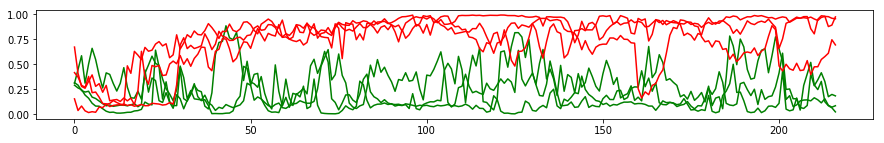

In [179]:
plot_df(results[7][2], ab_test.df)
save('tmo_wp_10_10_linear', results[7][2])

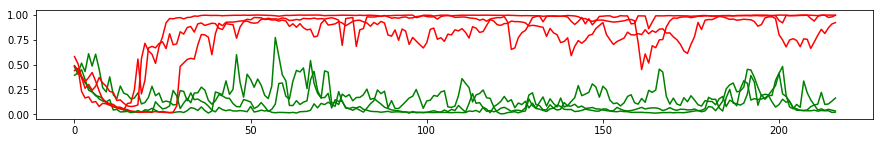

In [180]:
plot_df(results[9][2], ab_test.df)
save('tmo_wp_20_50_linear', results[9][2])

In [116]:
# > 10 epochs : overfit
conf = conf_base.spawn(experiment='longer', verbose=0, classes='tm_o', preprocessor='wp_20_20')
results = experiments([
    conf.spawn(epochs=epochs)
    for epochs in (10, 20, 50)
], ('epochs',))

#000                   10: 0.9055, 0.9040, 0.9263,  -> 0.9119 ± 0.0102  [8.4s ± 1.4s]
#001                   20: 0.8863, 0.8955, 0.9032,  -> 0.8950 ± 0.0069  [15.0s ± 1.1s]
#002                   50: 0.8817, 0.8564, 0.8856,  -> 0.8746 ± 0.0129  [36.4s ± 2.2s]


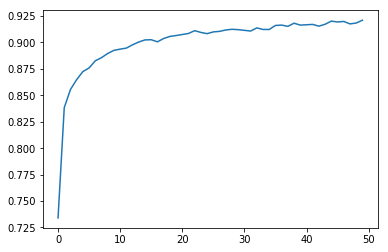

In [117]:
plt.plot(results[2][2].history['accuracy'])

In [119]:
# 2 epochs best ?
conf = conf_base.spawn(experiment='shorter', verbose=0, classes='tm_o', preprocessor='wp_20_20')
results = experiments([
    conf.spawn(epochs=epochs)
    for epochs in (1, 2, 5, 10, 15)
], ('epochs',))

#000                    1: 0.9017, 0.8986, 0.8771,  -> 0.8925 ± 0.0109  [1.5s ± 0.1s]
#001                    2: 0.9316, 0.9002, 0.9117,  -> 0.9145 ± 0.0130  [2.1s ± 0.0s]
#002                    5: 0.9224, 0.9178, 0.8909,  -> 0.9104 ± 0.0139  [4.2s ± 0.1s]
#003                   10: 0.8725, 0.9117, 0.8932,  -> 0.8925 ± 0.0160  [7.5s ± 0.3s]
#004                   15: 0.9140, 0.9063, 0.8840,  -> 0.9014 ± 0.0127  [11.1s ± 0.2s]


# use

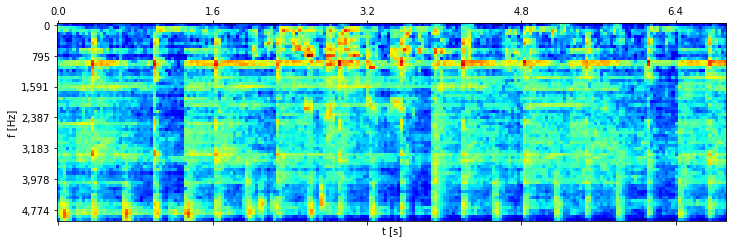

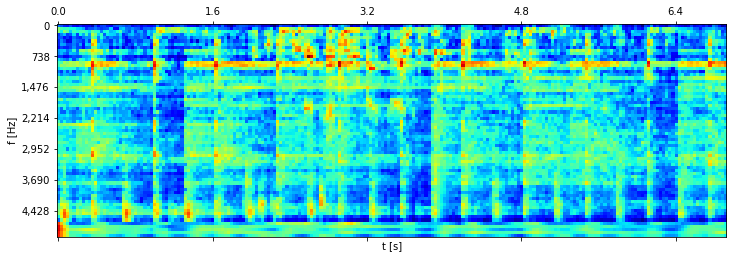

In [157]:
logmel = ab_train.df.logmel.iloc[0]
wp = S.WithPrevious(n=5, d=5)
util.plot_logmel(logmel, vmin=logmel.min(), vmax=logmel.max())
util.plot_logmel(np.concatenate([[wp(_)] for _ in logmel]), vmin=logmel.min(), vmax=logmel.max())

In [158]:
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_none_linear.h5'))
# preprocessor = lambda x: x
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_wp_5_5_linear.h5'))
# preprocessor = S.WithPrevious(n=5, d=5)
# model = tf.keras.models.load_model(os.path.join(model_dir, 'tmo_wp_10_10_linear.h5'))
# preprocessor = S.WithPrevious(n=10, d=10)
model = tf.keras.models.load_model(os.path.join(model_dir, 'tmo_wp_20_50_linear.h5'))
preprocessor = S.WithPrevious(n=20, d=50)

detector = S.KerasDetector(model, preprocessor)

In [272]:
ab_test.df.index

Index(['m_g_1', 'o_a_2', 'o_g_1', 'o_g_3', 't_a_2', 't_g_2', 'w_a_1'], dtype='object', name='name')

In [159]:
def logmel_pred(detectors, logmel):
    plt.figure(figsize=(15, 5))
    util.plot_logmel(logmel, ax=plt.subplot(211), aspect='auto')
    try: iter(detectors)
    except TypeError: detectors = (detectors,)
    ax = plt.subplot(212)
    for detector in detectors:
        ax.plot([detector(lm) for lm in logmel])

In [160]:
mf = S.MedianFilter(detector, n=4)
mf2 = S.MedianFilter(detector, n=10)
mf3 = S.MedianFilter(detector, n=10, threshold=0.5)
detectors = (detector, mf, mf2, mf3)

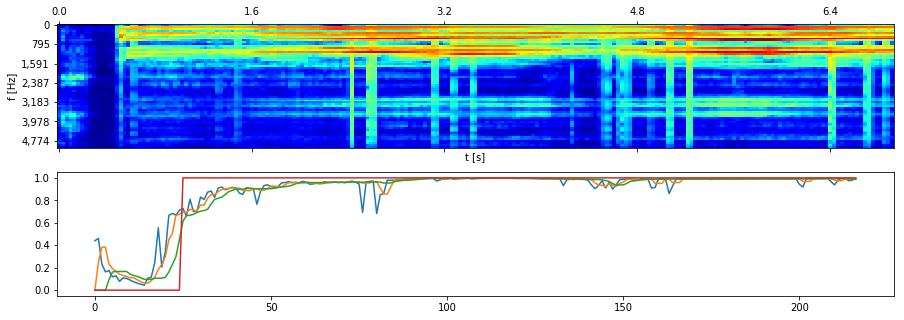

In [161]:
logmel_pred(detectors, ab_test.df.loc['o_a_2', 'logmel'])

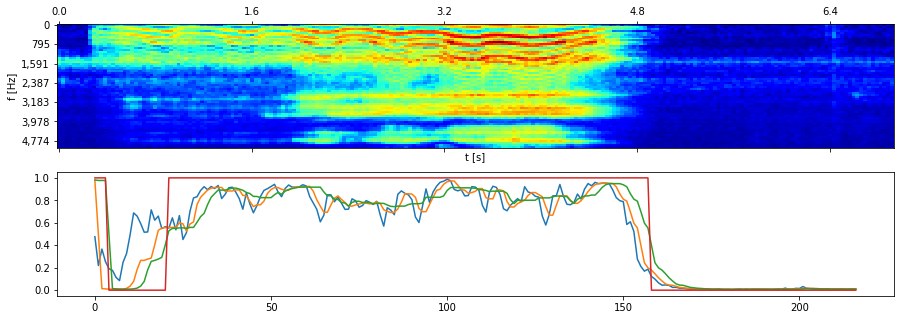

In [162]:
logmel_pred(detectors, ab_test.df.loc['w_a_1', 'logmel'])

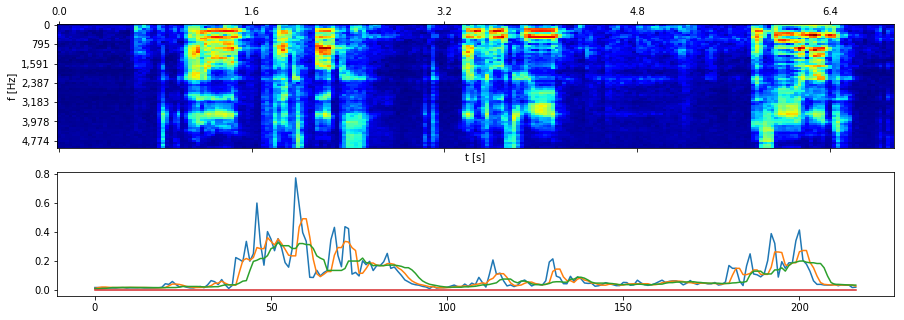

In [163]:
logmel_pred(detectors, ab_test.df.loc['t_g_2', 'logmel'])

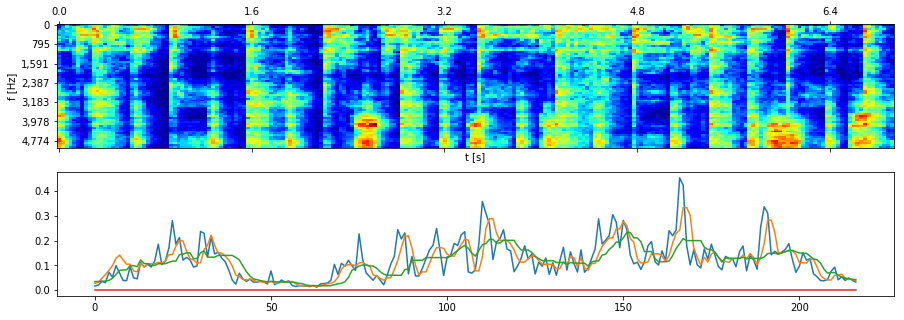

In [164]:
logmel_pred(detectors, ab_test.df.loc['m_g_1', 'logmel'])

# debug

## difference with monitor

nets with high accuracy on eval set have random behavior when inspecting with
recorder2.py/monitor.py

(from old version; behavior now fixed)

(3.7864342122603714, 11.126097687572154)

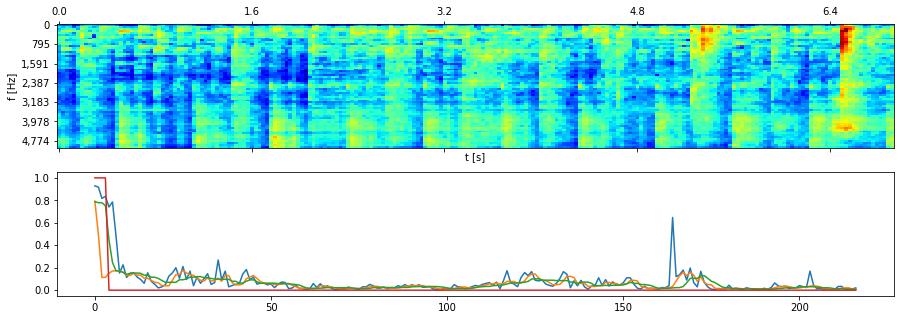

In [295]:
abase_logmel = ab_train.df.loc['m_g_3', 'logmel']
logmel_pred(detectors, abase_logmel)
abase_logmel.min(), abase_logmel.max()

(-4.52465800512057, 0.73370267448466)

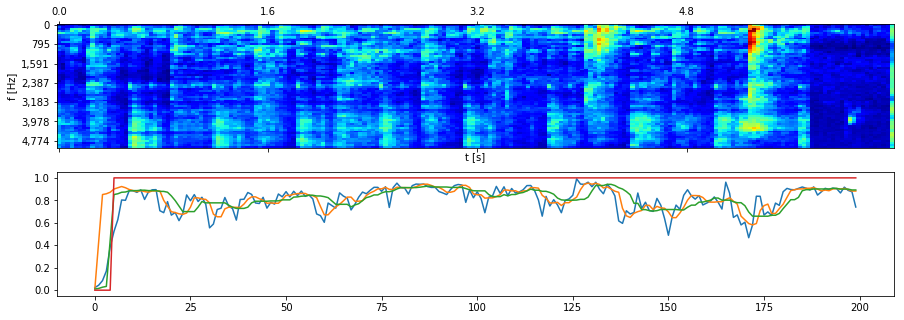

In [317]:
with open('../py/logmel001.pickle', 'rb') as f:
    monitor_logmel = pickle.load(f)
logmel_pred(detectors, monitor_logmel)
monitor_logmel.min(), monitor_logmel.max()

In [296]:
audio_interface = audio.AudioInterface(input_channels=1)
wav = audio_interface.record(secs=2)

* recording
* done recording


(4.048216484207795, 12.40923287137952)

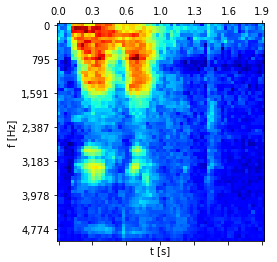

In [298]:
logmel = features.log_mel_spectrogram(wav)
util.plot_logmel(logmel)
logmel.min(), logmel.max()

In [310]:
scipy.io.wavfile.write('../recordings/test.wav', settings.rate, wav)
ab2 = abase.ABase(load_wav=True)

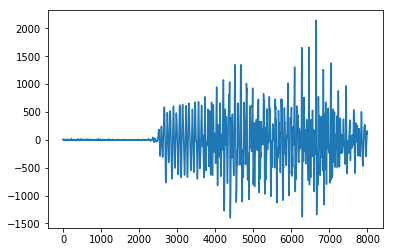

In [312]:
plt.plot(wav[:8000])

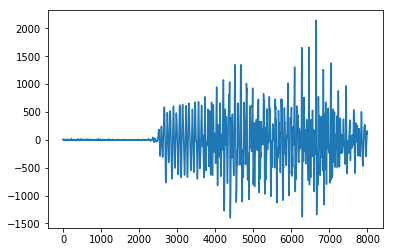

In [314]:
plt.plot(ab2.df.loc['test', 'wav'][:8000])

In [315]:
ab2.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))

Updated 36/36 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.74M (0.0s)


(4.048216484207795, 12.40923287137952)

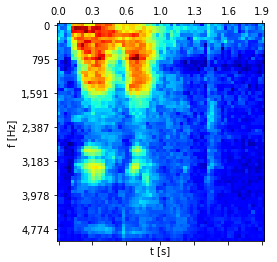

In [316]:
logmel_ = ab2.df.loc['test', 'logmel']
util.plot_logmel(logmel_)
logmel_.min(), logmel_.max()

In [318]:
# => culprit is scaling in util.int16_to_float() that is called from
#    recorder2.py but not in abase ...
wav_f = util.int16_to_float(wav)
logmel_f = features.log_mel_spectrogram(wav_f)
logmel_f.min(), logmel_f.max()

(-4.444054822334877, 2.0133614050072306)